# VGD Test

In [1]:
import jax
from jax import config
import jax.numpy as jnp
config.update("jax_enable_x64", True)  # do this at the very top

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]  # matches LaTeX default

import mplcyberpunk
plt.style.use("cyberpunk")

from test_targets import *

from vgd.methods import vgd, mfld, vgd_random, vgd_naive_random, vgd_weight
from vgd.kernel import RBFKernel, KernelParams
from vgd.loss import PredictionCentricLoss, SequenceLoss, PosteriorKLLoss, PredictionCentricLoss_n
from vgd.distribution import DiscreteMixture 

from vgd.util import plot_1d_output


## Build Toy Problems

$$ y_i \mid x_i, \theta \sim \mathcal{N}(f(\theta, x_i), \sigma^2), \quad \theta \mid x_i \sim \mathcal{N}(\mu_0, \sigma^2_0). $$


##### Build Mean Functions


1. **Quadratic**: $f(\theta, x) = \theta x^2$
2. **Sinusoidal**: $f(\theta, x) = \sin(\theta x)$


In [2]:
def quad_mean(theta: Array, x: Array) -> Array:
    """
    Predictive mean matrix with broadcasting:
      theta shape: (n,) or (n,d) with d=1
      x     shape: (N,)
    returns: (n, N)
    """
    theta = jnp.asarray(theta)
    if theta.ndim == 1:
        theta = theta[:, None]  # (n,1)
    x = jnp.asarray(x)[None, :]  # (1,N)
    return theta @ (x ** 2)      # (n,N)


def sinusoidal_mean(theta: Array, x: Array) -> Array:
    """
    Predictive mean matrix with broadcasting:
      theta shape: (n,) or (n,d) with d=1
      x     shape: (N,)
    returns: (n, N)
    """
    theta = jnp.asarray(theta)
    if theta.ndim == 1:
        theta = theta[:, None]  # (n,1)
    x = jnp.asarray(x)[None, :]  # (1,N)
    return jnp.sin(theta @ x)      # (n,N)


NameError: name 'Array' is not defined

##### Build Priors

In [5]:
prior_mean = 0.0
prior_sd = 1.0

key = jax.random.PRNGKey(0)

prior = NormalDiag(mean=prior_mean, sd=prior_sd)

#### Build Likelihoods, Generate Data and Build Posteriors

In [ ]:
like_quad  = ToyLikelihood(pred_mean_fn=quad_mean)
like_sin  = ToyLikelihood(pred_mean_fn=sinusoidal_mean)

# Make synthetic data
N = 200 # number of data points
x = jnp.linspace(-2., 2., N)

# Quadratic Model: well-specified dataset (single θ)
key, theta_quad_true, data_quad = sample_toy_dataset(
    key, x=x, prior=prior, true_theta=0.7, obs_sd=0.3,
    per_datum_theta=False, pred_mean_fn=quad_mean
)

# Quadratic Model: misspecified dataset (θ_i vary around 0.7 with sd=0.7)
key, theta_quad_vec, data_quad_mis = sample_toy_dataset(
    key, x=x, prior=prior, true_theta=0.7, obs_sd=0.3,
    theta_sd=0.7, per_datum_theta=True, pred_mean_fn=quad_mean
)

# Sinusoidal Model: well-specified dataset (single θ)
key, theta_sin_true, data_sin = sample_toy_dataset(
    key, x=x, prior=prior, true_theta=1.7, obs_sd=0.3,
    per_datum_theta=False, pred_mean_fn=sinusoidal_mean
)

# Sinusoidal Model: misspecified dataset (θ_i vary around 0.7 with sd=0.7)
key, theta_sin_vec, data_sin_mis = sample_toy_dataset(
    key, x=x, prior=prior, true_theta=1.7, obs_sd=0.3,
    theta_sd=0.7, per_datum_theta=True, pred_mean_fn=sinusoidal_mean
)

# Bind to Posteriors
post_quad = Posterior(like=like_quad, prior=prior, data=data_quad)
post_quad_mis = Posterior(like=like_quad, prior=prior, data=data_quad_mis)

post_sin = Posterior(like=like_sin, prior=prior, data=data_sin)
post_sin_mis = Posterior(like=like_sin, prior=prior, data=data_sin_mis)

post_sin_mis_quad = Posterior(like=like_sin, prior=prior, data=data_quad) # Misspecified Sinusoidal on Quadratic Data

### Plot Synthetic Data

Text(0.5, 1.0, 'Misspecified Sample (Sinusoidal)')

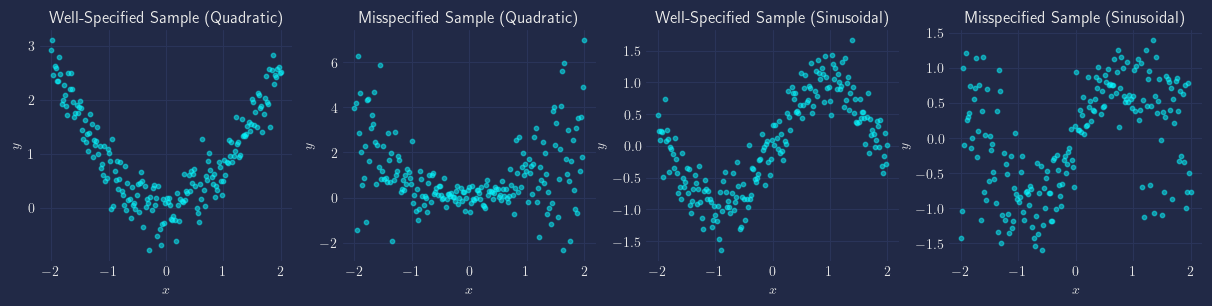

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3), sharex=True, sharey=False)
axes[0].scatter(data_quad['x'], data_quad['y'], s=10, alpha=0.5, label='Sampled Data')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$y$')
axes[0].set_title('Well-Specified Sample (Quadratic)')

axes[1].scatter(data_quad_mis['x'], data_quad_mis['y'], s=10, alpha=0.5, label='Sampled Data')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$y$')
axes[1].set_title('Misspecified Sample (Quadratic)')

axes[2].scatter(data_sin['x'], data_sin['y'], s=10, alpha=0.5, label='Sampled Data')
axes[2].set_xlabel('$x$')
axes[2].set_ylabel('$y$')
axes[2].set_title('Well-Specified Sample (Sinusoidal)')

axes[3].scatter(data_sin_mis['x'], data_sin_mis['y'], s=10, alpha=0.5, label='Sampled Data')
axes[3].set_xlabel('$x$')
axes[3].set_ylabel('$y$')
axes[3].set_title('Misspecified Sample (Sinusoidal)')

### Define Global Parameters

All algorithms with *Prediction Centric* loss:

$$ \mathcal{L}(Q) = -\sum_{i=1}^N \log \int p(y_i \mid x_i, \theta)\,\mathrm{d}Q(\theta). $$

In [10]:
n_particles = 32 # number of particles used
loss = PredictionCentricLoss(alpha=1.)
loss2 = PredictionCentricLoss_n(alpha=1.)

kparams = KernelParams(lengthscale=jnp.asarray(1.), amplitude=jnp.asarray(1.0)) # always use median lengthscale so initial choice doesn't matter

## VGD

Vanilla VGD.

### Quadratic

#### Well-Specifed

In [11]:
key, subkey = jax.random.split(key)
particles0 = prior.sample(subkey, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)
    
out = vgd(model=post_quad, loss=loss, kernel=RBFKernel(), kparams=kparams, eps=0.02, Q0=Q0, steps=5000, repulse_coef=1., use_median_lengthscale=True, return_metrics=True)

Q_vgd_quad, hist_vgd_quad = out  # unpack


(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

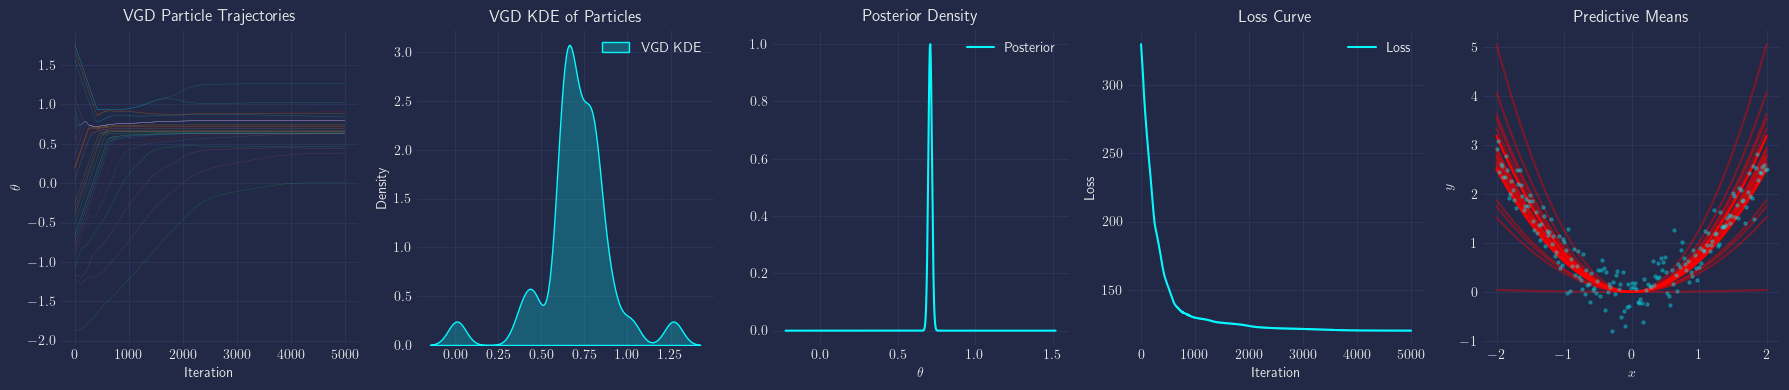

In [12]:
plot_1d_output(Q_vgd_quad, hist_vgd_quad, post_quad, algo_name="VGD")

In [13]:
key, subkey = jax.random.split(key)
particles0 = prior.sample(subkey, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)
    
out = vgd(model=post_quad, loss=loss2, kernel=RBFKernel(), kparams=kparams, eps=0.02, Q0=Q0, steps=5000, repulse_coef=1., use_median_lengthscale=True, return_metrics=True)

Q_vgd_quad, hist_vgd_quad = out  # unpack


(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

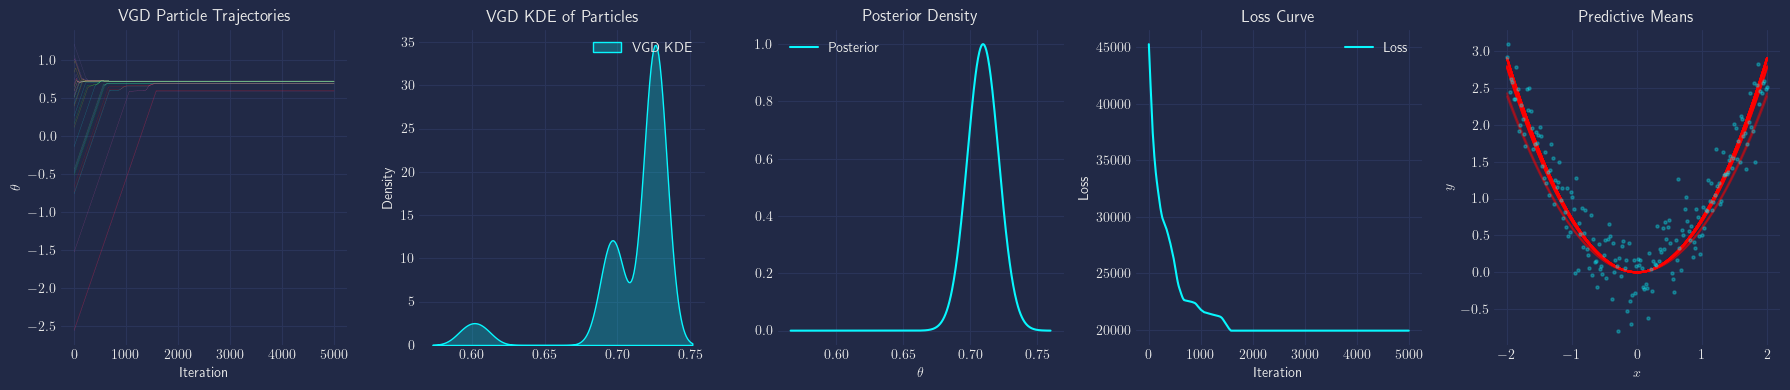

In [14]:
plot_1d_output(Q_vgd_quad, hist_vgd_quad, post_quad, algo_name="VGD")

#### Misspecified

In [15]:
key, subkey = jax.random.split(key)
particles0 = prior.sample(subkey, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)
    
out = vgd(model=post_quad_mis, loss=loss, kernel=RBFKernel(), kparams=kparams, eps=0.02, Q0=Q0, steps=5000, repulse_coef=1., use_median_lengthscale=True, return_metrics=True)

Q_vgd_mis_quad, hist_vgd_mis_quad = out  # unpack


(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

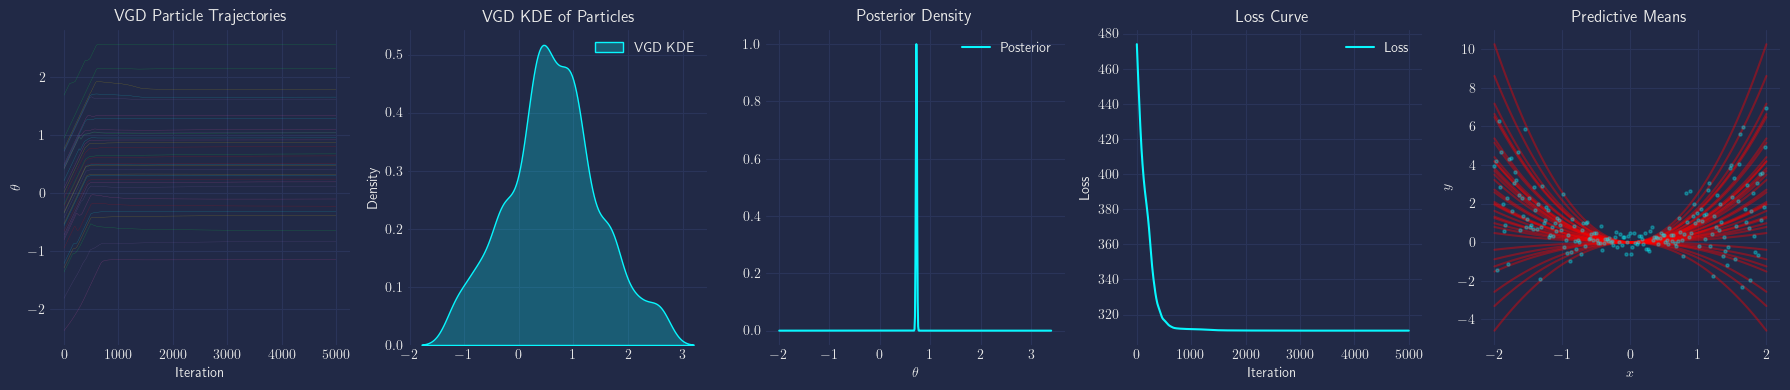

In [16]:
plot_1d_output(Q_vgd_mis_quad, hist_vgd_mis_quad, post_quad_mis, algo_name="VGD")

In [17]:
key, subkey = jax.random.split(key)
particles0 = prior.sample(subkey, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)
    
out = vgd(model=post_quad_mis, loss=loss2, kernel=RBFKernel(), kparams=kparams, eps=0.02, Q0=Q0, steps=5000, repulse_coef=1., use_median_lengthscale=True, return_metrics=True)

Q_vgd_mis_quad, hist_vgd_mis_quad = out  # unpack


(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

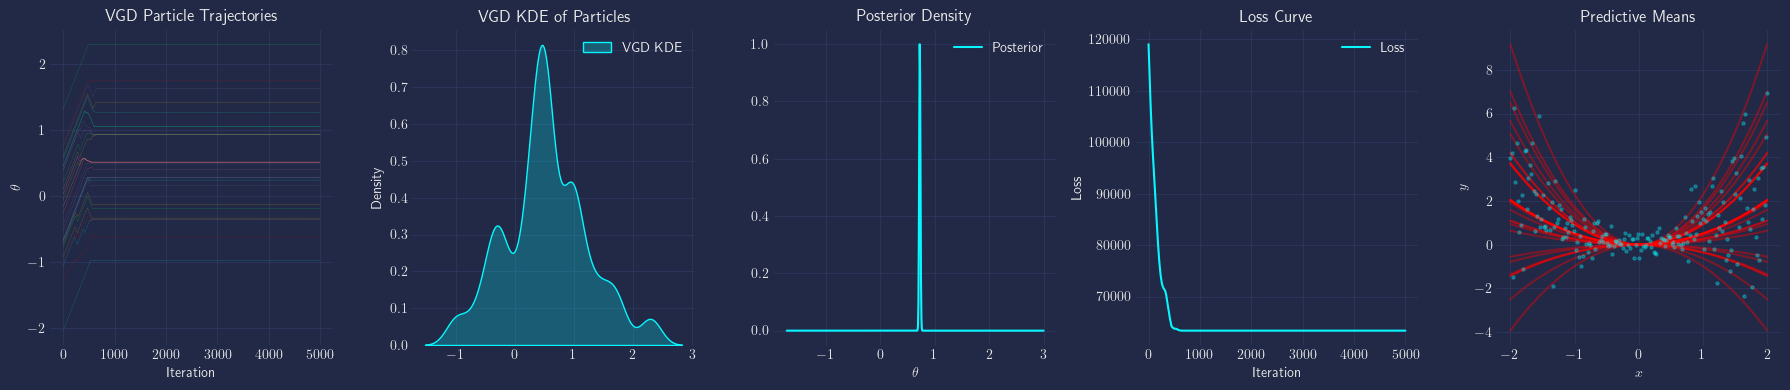

In [18]:
plot_1d_output(Q_vgd_mis_quad, hist_vgd_mis_quad, post_quad_mis, algo_name="VGD")

### Sinusoidal

#### Well-Specified

In [11]:
key, subkey = jax.random.split(key)
particles0 = prior.sample(subkey, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)
    
out = vgd(model=post_sin, loss=loss, kernel=RBFKernel(), kparams=kparams, eps=0.02, Q0=Q0, steps=5000, repulse_coef=1., use_median_lengthscale=True, return_metrics=True)

Q_vgd_sin, hist_vgd_sin = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

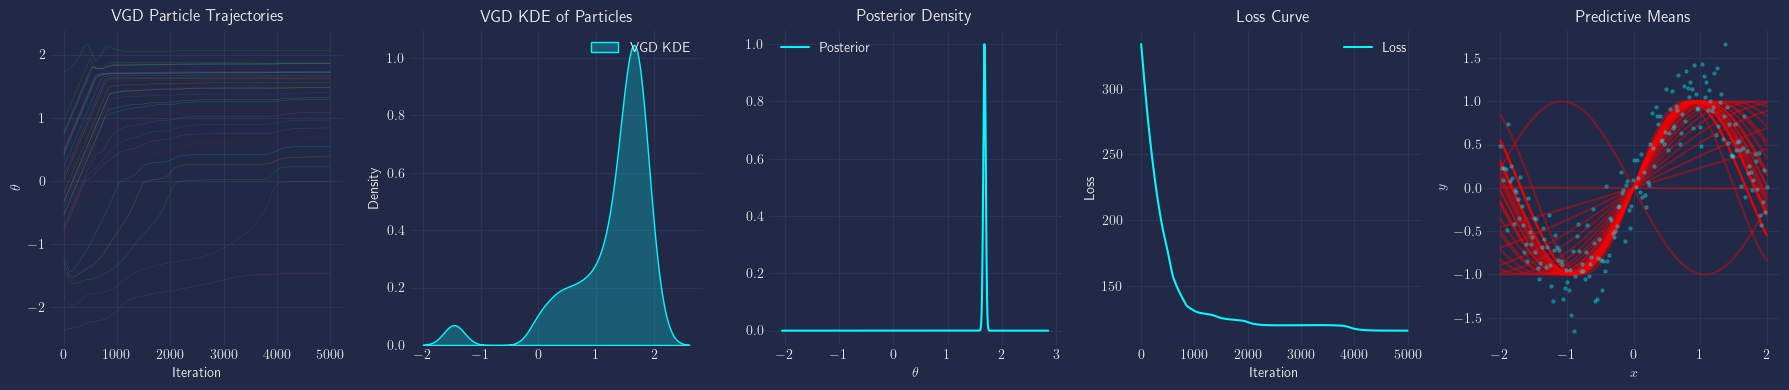

In [12]:
plot_1d_output(Q_vgd_sin, hist_vgd_sin, post_sin, algo_name="VGD")

#### Misspecified (Sinusoidal)

In [13]:
key, subkey = jax.random.split(key)
particles0 = prior.sample(subkey, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)
    
out = vgd(model=post_sin_mis, loss=loss, kernel=RBFKernel(), kparams=kparams, eps=0.02, Q0=Q0, steps=5000, repulse_coef=1., use_median_lengthscale=True, return_metrics=True)

Q_vgd_mis_sin, hist_vgd_mis_sin = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

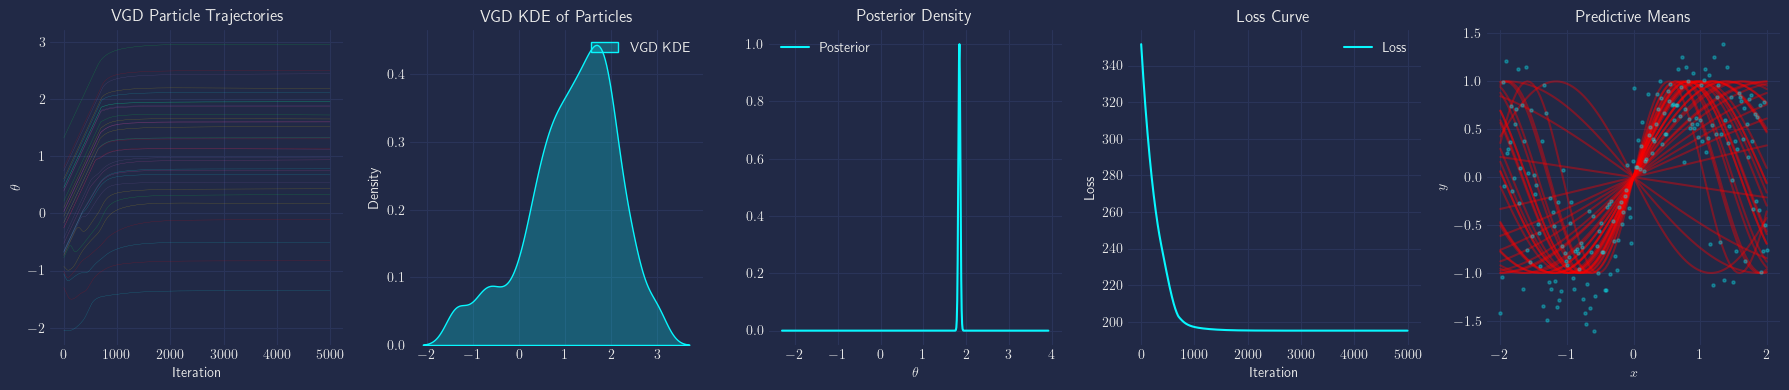

In [14]:
plot_1d_output(Q_vgd_mis_sin, hist_vgd_mis_sin, post_sin_mis, algo_name="VGD")

#### Misspecified (Quadratic)

In [15]:
key, subkey = jax.random.split(key)
particles0 = prior.sample(subkey, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)
    
out = vgd(model=post_sin_mis_quad, loss=loss, kernel=RBFKernel(), kparams=kparams, eps=0.02, Q0=Q0, steps=5000, repulse_coef=1., use_median_lengthscale=True, return_metrics=True)

Q_vgd_mis_sin_quad, hist_vgd_mis_sin_quad = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

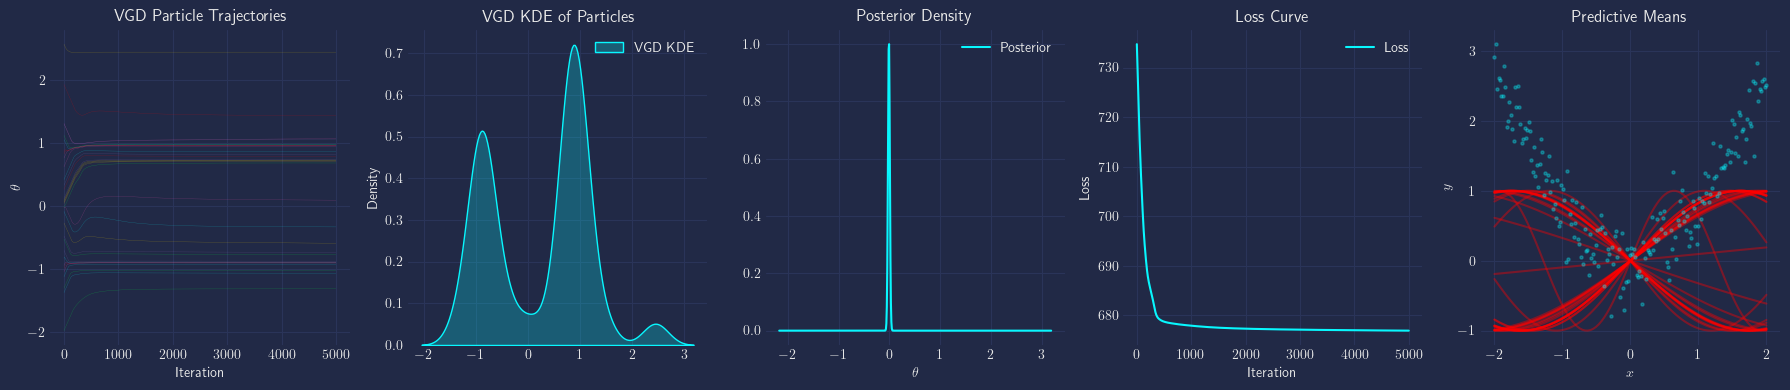

In [16]:
plot_1d_output(Q_vgd_mis_sin_quad, hist_vgd_mis_sin_quad, post_sin_mis_quad, algo_name="VGD")

## Mean Field Langevin Dynamics

Vanilla MFLD.

### Quadratic

#### Well-Specified

In [17]:
key, subkey1, subkey2 = jax.random.split(key, 3)
particles0 = prior.sample(subkey1, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)

out = mfld(model=post_quad, loss=loss, key=subkey2, Q0=Q0, steps=10000, return_metrics=True, temperature=0.0, lr=1e-3)

Q_mfld_quad, hist_mfld_quad = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'MFLD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'MFLD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

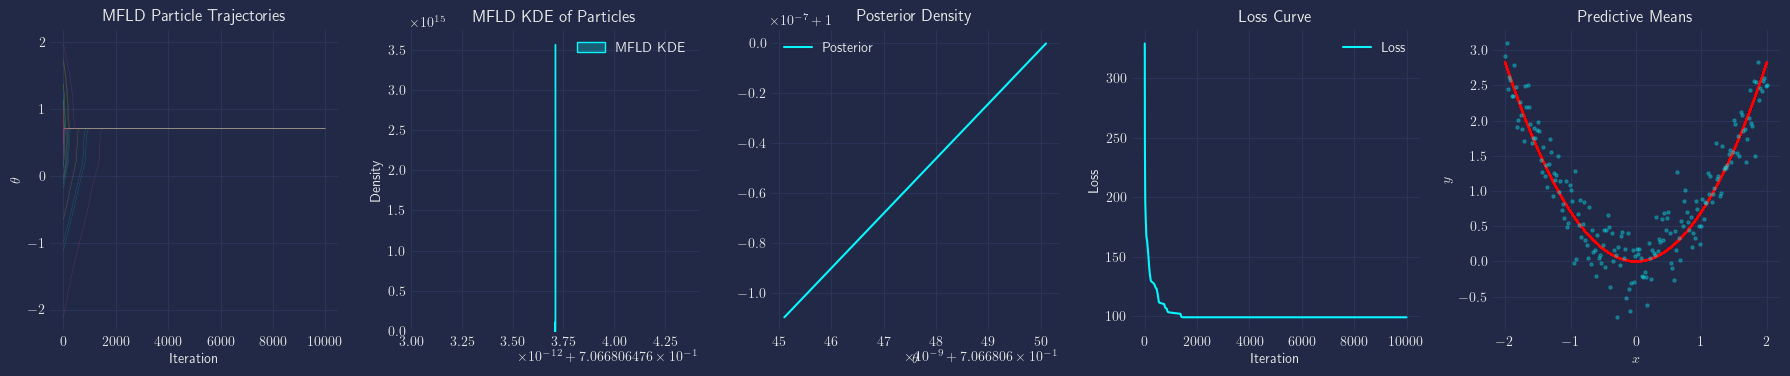

In [18]:
plot_1d_output(Q_mfld_quad, hist_mfld_quad, post_quad, algo_name="MFLD")

#### Misspecified

In [19]:
key, subkey1, subkey2 = jax.random.split(key, 3)
particles0 = prior.sample(subkey1, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)

out = mfld(model=post_quad_mis, loss=loss, key=subkey2, Q0=Q0, steps=10000, return_metrics=True, temperature=0.0, lr=1e-3)

Q_mfld_mis_quad, hist_mfld_mis_quad = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'MFLD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'MFLD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

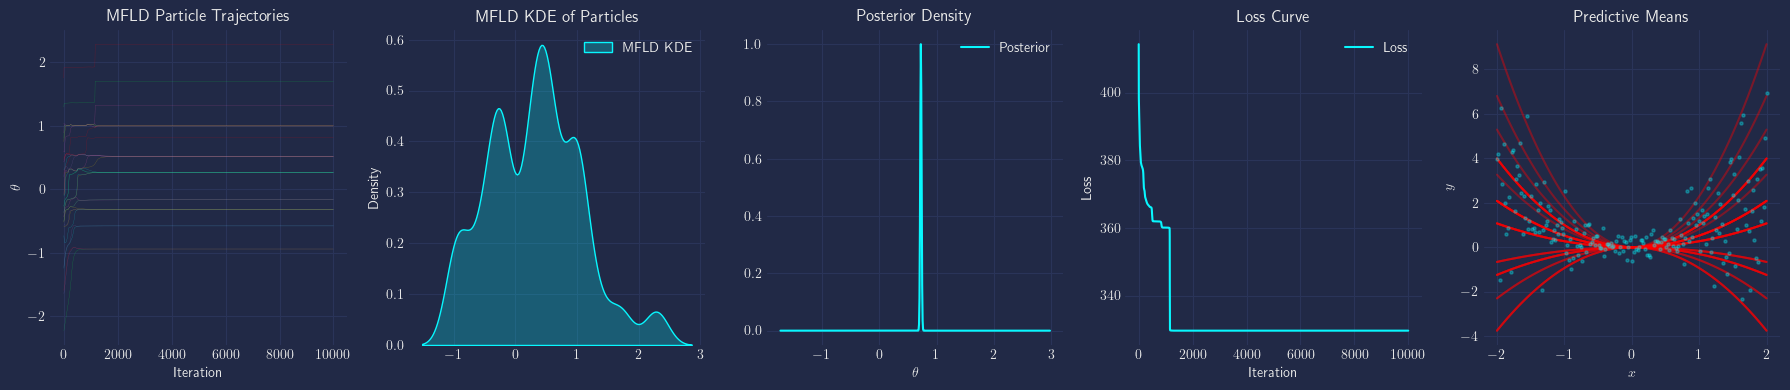

In [20]:
plot_1d_output(Q_mfld_mis_quad, hist_mfld_mis_quad, post_quad_mis, algo_name="MFLD")

### Sinusoidal

#### Well-Specified

In [21]:
key, subkey1, subkey2 = jax.random.split(key, 3)
particles0 = prior.sample(subkey1, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)

out = mfld(model=post_sin, loss=loss, key=subkey2, Q0=Q0, steps=10000, return_metrics=True, temperature=0.0, lr=1e-4)

Q_mfld_sin, hist_mfld_sin = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'MFLD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'MFLD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

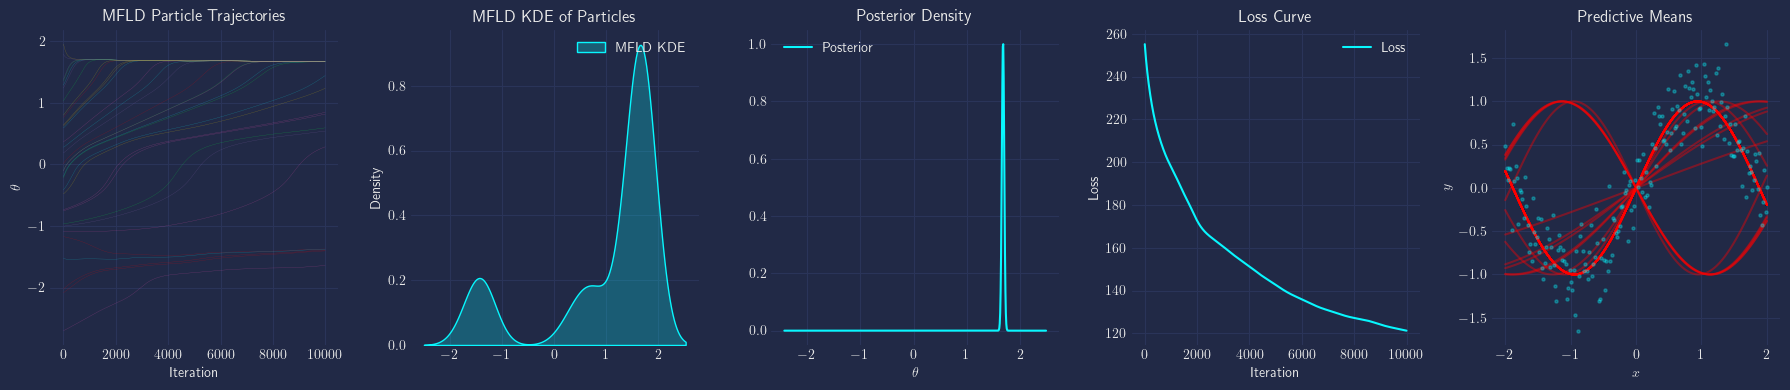

In [22]:
plot_1d_output(Q_mfld_sin, hist_mfld_sin, post_sin, algo_name="MFLD")

#### Misspecified (Sinusoidal)

In [23]:
key, subkey1, subkey2 = jax.random.split(key, 3)
particles0 = prior.sample(subkey1, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)

out = mfld(model=post_sin_mis, loss=loss, key=subkey2, Q0=Q0, steps=10000, return_metrics=True, temperature=0.0, lr=1e-4)

Q_mfld_mis_sin, hist_mfld_mis_sin = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'MFLD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'MFLD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

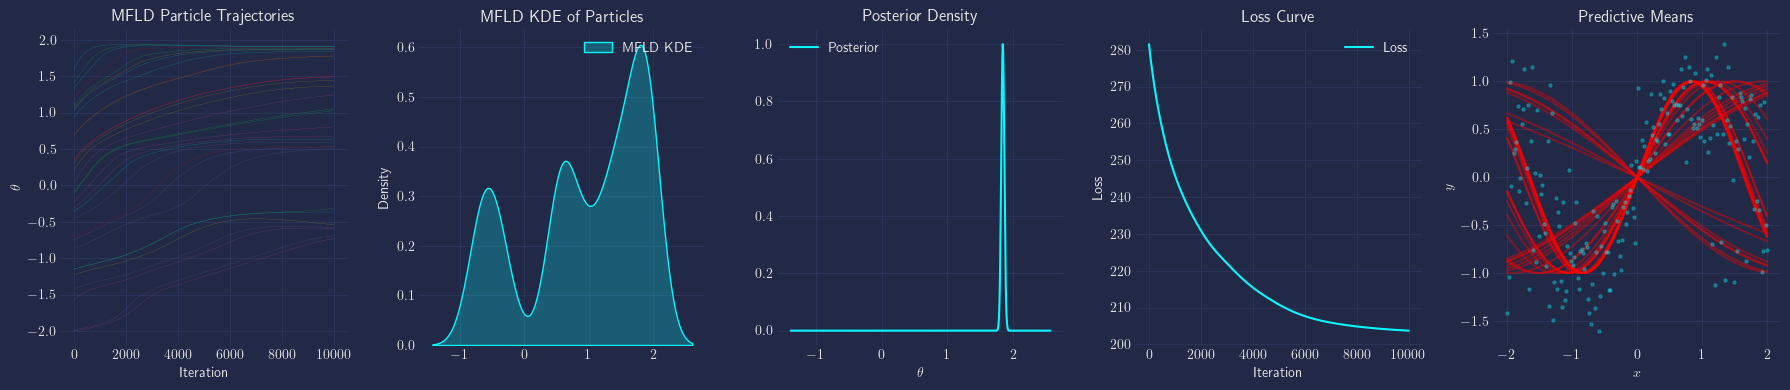

In [24]:
plot_1d_output(Q_mfld_mis_sin, hist_mfld_mis_sin, post_sin_mis, algo_name="MFLD")

#### Misspecified (Quadratic)

In [25]:
key, subkey1, subkey2 = jax.random.split(key, 3)
particles0 = prior.sample(subkey1, (n_particles,1)) # initial particles
Q0 = DiscreteMixture(particles0)

out = mfld(model=post_sin_mis_quad, loss=loss, key=subkey2, Q0=Q0, steps=10000, return_metrics=True, temperature=0.0, lr=1e-4)

Q_mfld_mis_sin_quad, hist_mfld_mis_sin_quad = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'MFLD Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'MFLD KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

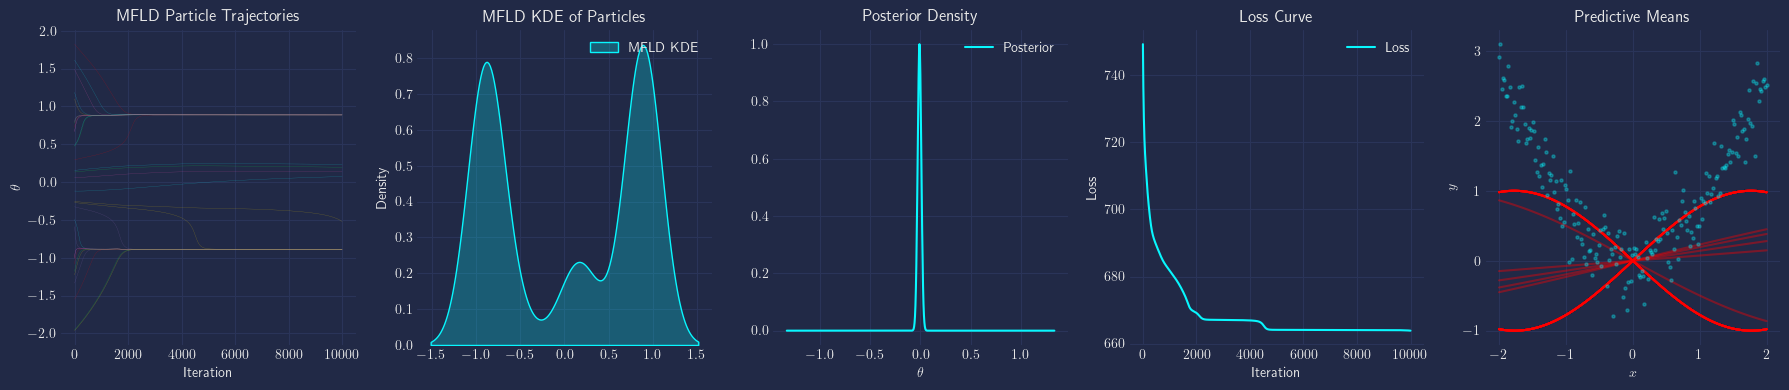

In [26]:
plot_1d_output(Q_mfld_mis_sin_quad, hist_mfld_mis_sin_quad, post_sin_mis_quad, algo_name="MFLD")

## Stochastic VGD

Target objective 

$$ \mathcal{F}(Q) = \mathcal{L}(Q) + \mathrm{KLD}(Q\|Q_0). $$

The Stochastic VGD algorithm implements a VGD step followed by an Langevin step. This is achieved by decomposing the objective as

$$ \mathcal{F}(Q) = \mathcal{F}_\lambda(Q) + \mathcal{F}_{1-\lambda}(Q), \quad 0 \leq \lambda \leq 1, $$

where 

$$ \mathcal{F}_\lambda(Q) = \mathcal{L}(Q) + \lambda \, \mathrm{KLD}(Q\|Q_0) \quad \text{and} \quad \mathcal{F}_{1-\lambda}(Q) = (1 - \lambda) \mathrm{KLD}(Q\|Q_0). $$

The VGD step targets $\mathcal{F}_\lambda$, the Langevin step targets $\mathcal{F}_{1-\lambda}$.

#### VGD Step

The VGD step kernelises the scaled objective:

$$ \mathcal{F}_\lambda(Q) = \mathcal{L}(Q) + \lambda \, \mathrm{KLD}(Q\|Q_0). $$

For a (weighted) discrete measure

$$ Q^{(t)} = \sum_{i=1}^n w_i \, \delta_{\theta_i^{(t)}},\quad \text{where} \quad \sum_{i=1}^n w_i = 1, $$

this corresponds to the following update:

$$ \theta_i^{(t+\lambda)} \leftarrow \; \theta_i^{(t)} + \epsilon \left[  \sum_{j=1}^n w_j k\left(\theta_j^{(t)}, \theta_i^{(t)}\right) \left(\lambda \, \nabla \log q_0 - \nabla_W \mathcal{L}(Q^{(t)})\right)(\theta^{(t)}_j) + \lambda \sum_{j=1}^n w_j \nabla_1 k\left(\theta_j^{(t)}, \theta_i^{(t)}\right)  \right]. $$

#### Langevin Step

The Langevin step targets:

$$ \mathcal{F}_{1-\lambda}(Q) = (1 - \lambda) \mathrm{KLD}(Q\|Q_0). $$

The KLD decomposes as

$$\mathrm{KLD}(Q \| Q_0) = \int \log \frac{\mathrm{d}Q}{\mathrm{d}Q_0} \,\mathrm{d}Q = \int \log q \,\mathrm{d}Q - \int \log q_0 \,\mathrm{d}Q = \mathrm{Ent}[Q] - \int \log q_0 \,\mathrm{d}Q_0.$$

So the corresponding McKean-Vlasov SDE is:

$$ \mathrm{d}\theta_t = - \nabla \log q_0(\theta_t)\,\mathrm{d}\theta_t + \sqrt{2(1-\lambda)} \mathrm{d}Z_t. $$

Thus an Euler-Mauryama discretisation is (same step-size $\epsilon$):

$$ \theta_i^{(t+1)} \leftarrow \theta_i^{(t+\lambda)} + \epsilon(1-\lambda) (\nabla \log q_0)(\theta_i^{(t + \lambda)}) + \sqrt{2\epsilon(1-\lambda)} Z_i^{(t)}, \quad Z_i^{(t)}\sim \mathcal{N}(0,I). $$

In practice this is implemented as a Strang split (half Langevin step -> VGD step -> half Langevin step).


### Quadratic

#### Well-Specified

In [27]:
key, subkey1, subkey2 = jax.random.split(key, 3)
prior_sample = prior.sample(subkey1, (n_particles,1)) + 5
Q0 = DiscreteMixture(prior_sample)

out = vgd_random(model=post_quad, loss=loss, kernel=RBFKernel(), key=subkey2, kparams=kparams, eps=0.01, Q0=Q0, steps=8000, use_median_lengthscale=True, return_metrics=True, step_clip=100., lambd=0.5)

Q_vgdrandom_quad, hist_vgdrandom_quad = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD (Random) Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD (Random) KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

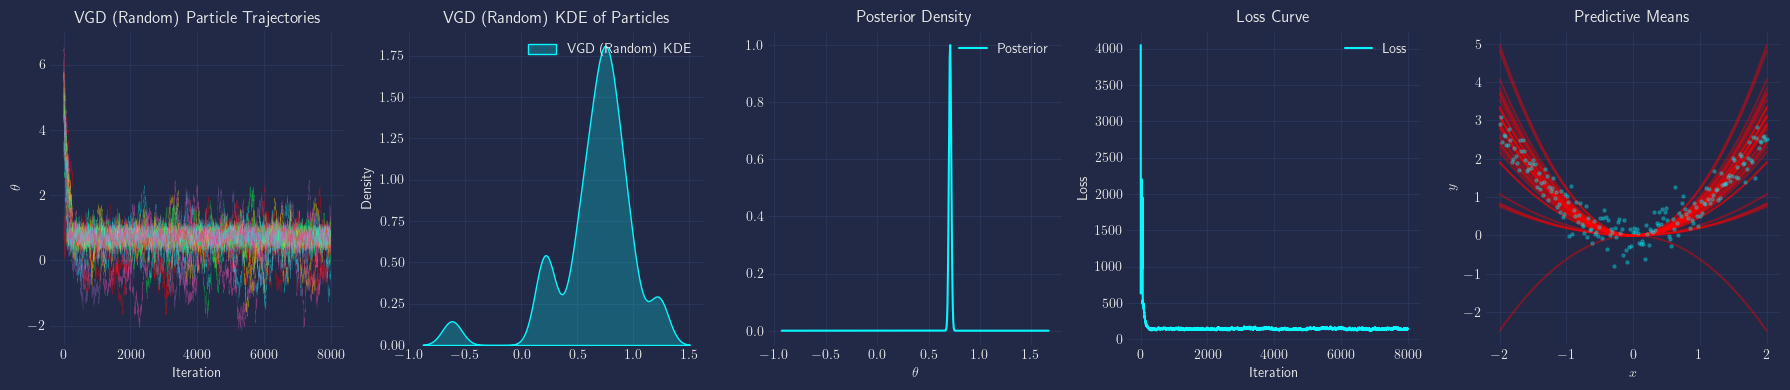

In [28]:
plot_1d_output(Q_vgdrandom_quad, hist_vgdrandom_quad, post_quad, algo_name="VGD (Random)")

#### Misspecified

In [29]:
key, subkey1, subkey2 = jax.random.split(key, 3)
prior_sample = prior.sample(subkey1, (n_particles,1)) + 5
Q0 = DiscreteMixture(prior_sample)

out = vgd_random(model=post_quad_mis, loss=loss, kernel=RBFKernel(), key=subkey2, kparams=kparams, eps=0.01, Q0=Q0, steps=8000, use_median_lengthscale=True, return_metrics=True, step_clip=100., lambd=0.5)

Q_vgdrandom_mis_quad, hist_vgdrandom_mis_quad = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD (Random) Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD (Random) KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

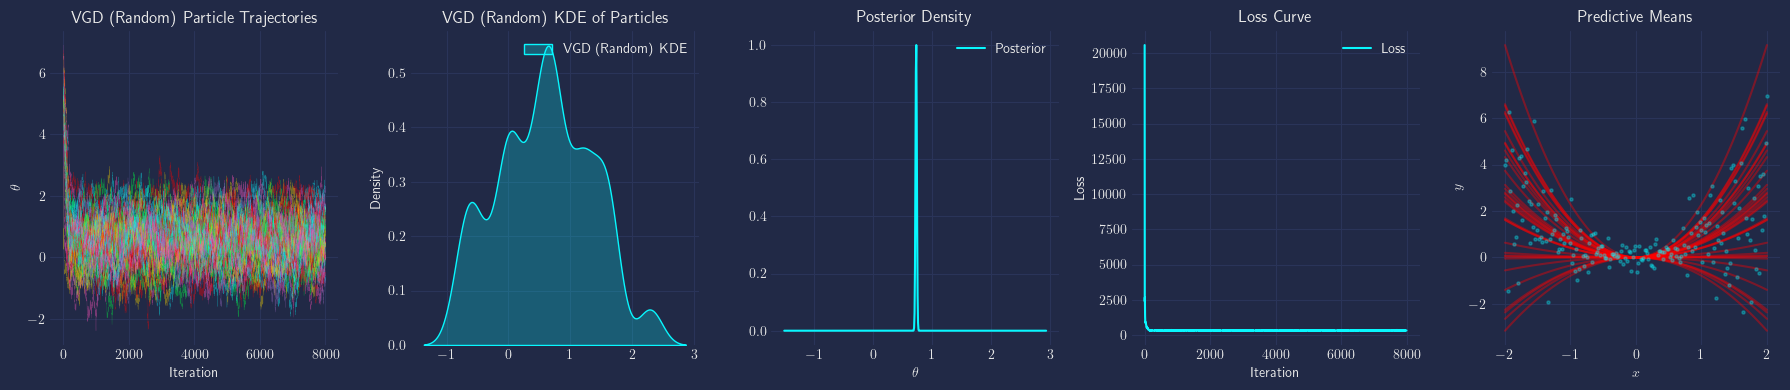

In [30]:
plot_1d_output(Q_vgdrandom_mis_quad, hist_vgdrandom_mis_quad, post_quad_mis, algo_name="VGD (Random)")

### Sinusoidal

#### Well-Specified

In [31]:
key, subkey1, subkey2 = jax.random.split(key, 3)
prior_sample = prior.sample(subkey1, (n_particles,1)) + 5
Q0 = DiscreteMixture(prior_sample)

out = vgd_random(model=post_sin, loss=loss, kernel=RBFKernel(), key=subkey2, kparams=kparams, eps=0.01, Q0=Q0, steps=8000, use_median_lengthscale=True, return_metrics=True, step_clip=100., lambd=0.5)

Q_vgdrandom_sin, hist_vgdrandom_sin = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD (Random) Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD (Random) KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

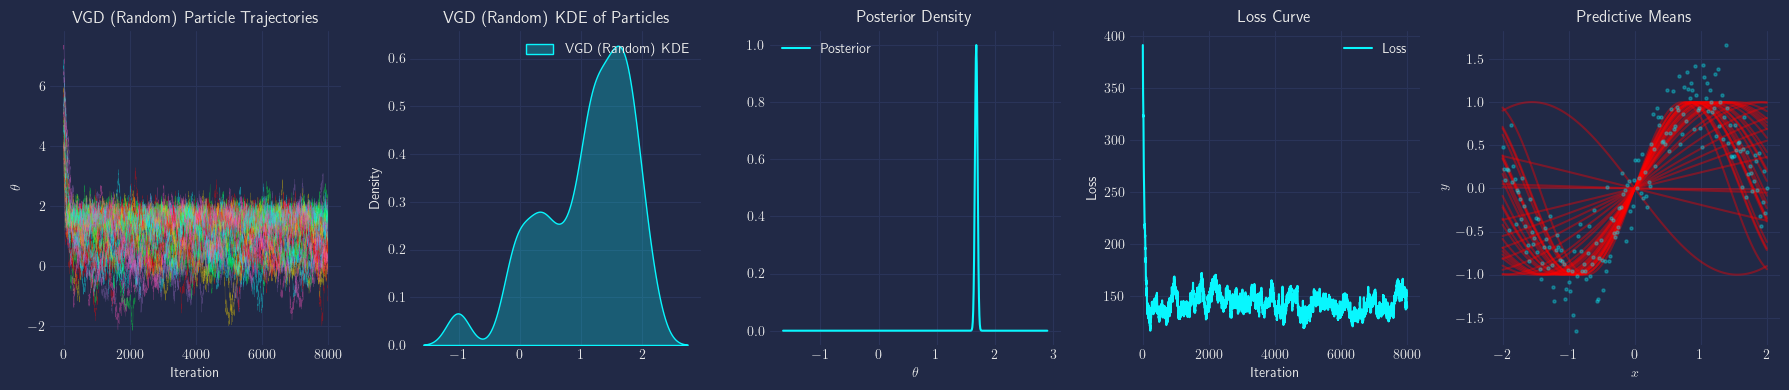

In [32]:
plot_1d_output(Q_vgdrandom_sin, hist_vgdrandom_sin, post_sin, algo_name="VGD (Random)")

#### Misspecified (Sinusoidal)

In [33]:
key, subkey1, subkey2 = jax.random.split(key, 3)
prior_sample = prior.sample(subkey1, (n_particles,1)) + 5
Q0 = DiscreteMixture(prior_sample)

out = vgd_random(model=post_sin_mis, loss=loss, kernel=RBFKernel(), key=subkey2, kparams=kparams, eps=0.01, Q0=Q0, steps=8000, use_median_lengthscale=True, return_metrics=True, step_clip=100., lambd=0.5)

Q_vgdrandom_mis_sin, hist_vgdrandom_mis_sin = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD (Random) Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD (Random) KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

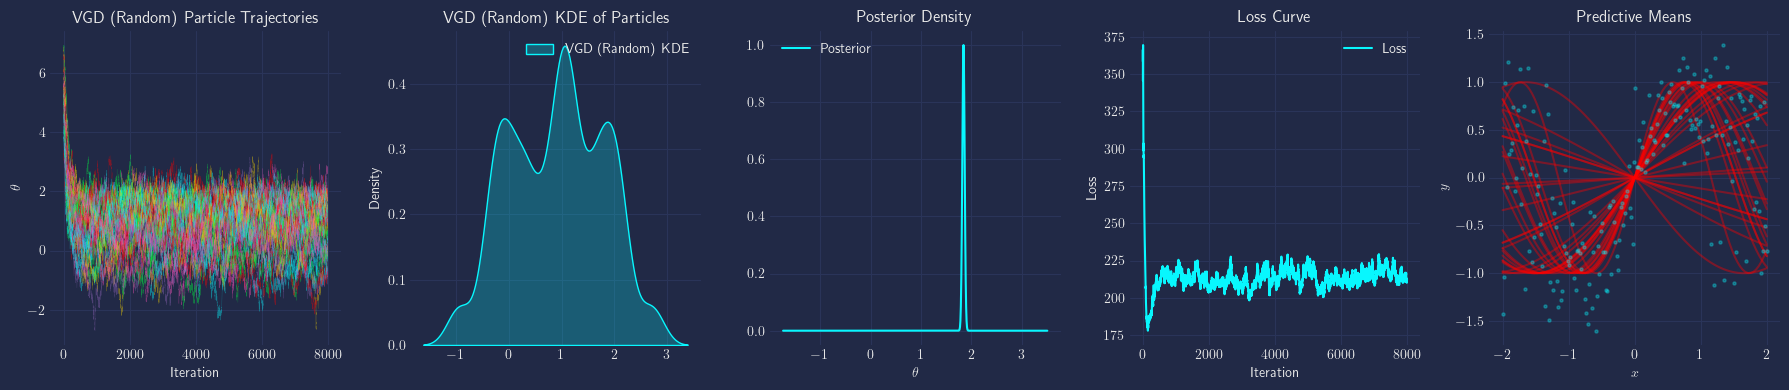

In [34]:
plot_1d_output(Q_vgdrandom_mis_sin, hist_vgdrandom_mis_sin, post_sin_mis, algo_name="VGD (Random)")

#### Misspecified (Quadratic)

In [35]:
key, subkey1, subkey2 = jax.random.split(key, 3)
prior_sample = prior.sample(subkey1, (n_particles,1)) + 5
Q0 = DiscreteMixture(prior_sample)

out = vgd_random(model=post_sin_mis_quad, loss=loss, kernel=RBFKernel(), key=subkey2, kparams=kparams, eps=0.01, Q0=Q0, steps=8000, use_median_lengthscale=True, return_metrics=True, step_clip=100., lambd=0.5)

Q_vgdrandom_mis_sin_quad, hist_vgdrandom_mis_sin_quad = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD (Random) Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD (Random) KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

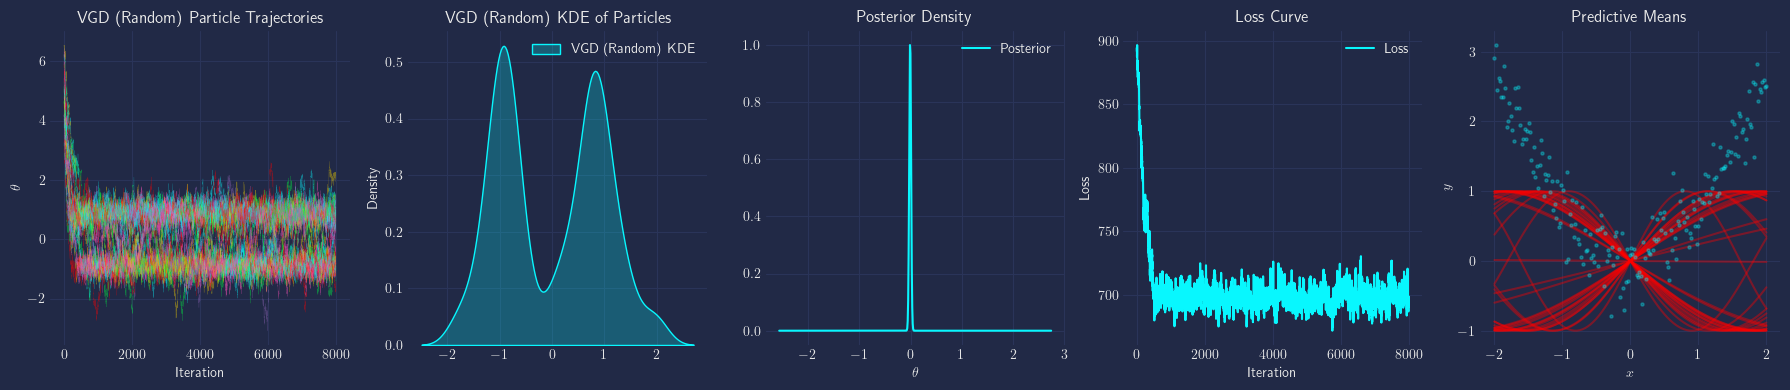

In [36]:
plot_1d_output(Q_vgdrandom_mis_sin_quad, hist_vgdrandom_mis_sin_quad, post_sin_mis_quad, algo_name="VGD (Random)")

## VGD with weight updates

Interleave a kernelised VGD update with a convex weight update (similar idea in: https://arxiv.org/pdf/2210.00462). For a (weighted) discrete measure

$$ Q^{(t)} = \sum_{i=1}^n w_i^{(t)} \, \delta_{\theta_i^{(t)}},\quad \text{where} \quad \sum_{i=1}^n w_i^{(t)} = 1, $$

the standard VGD update is:

$$ \theta_i^{(t+1)} \leftarrow \; \theta_i^{(t)} + \epsilon \left[  \sum_{j=1}^n w_j^{(t)} k\left(\theta_j^{(t)}, \theta_i^{(t)}\right) \left( \, \nabla \log q_0 - \nabla_W \mathcal{L}(Q^{(t)})\right)(\theta^{(t)}_j) +  \sum_{j=1}^n w_j^{(t)} \nabla_1 k\left(\theta_j^{(t)}, \theta_i^{(t)}\right)  \right]. $$

Then, perform a weight update targeting the objective $\mathcal{F}(Q) = \mathcal{L}(Q) + \mathrm{KLD}(Q \| Q_0)$. There are a couple of reasonable ways to do a *relaxed* weight update:
1. **Convex (implemented)**: Coefficient $\beta\in [0,1]$, update $w^{(t+1)} \leftarrow \; (1-\beta) w^{(t)} + \beta w_{new}^{(t+1)}$.
2. **Multiplicative/EMA (not implemented):** Coefficient $\beta\in [0,1]$, update $\log w^{(t+1)} \leftarrow \; (1-\beta) \log w^{(t)} + \beta \log w_{new}^{(t+1)}$ and normalise.

Since $Q$ is not absolutely continuous w.r.t. $Q_0$, dealing with the regularising term $\mathrm{KLD}(Q \| Q_0)$ is hard. We have a few options:

1. **Option 1 (implemented):** Switch objective to just $\mathcal{L}(Q)$, which corresponds to the fixed-point $Q^* \propto \exp(-\tfrac{\delta \mathcal{L}}{\delta Q}(Q^*))$. This corresponds to a convex update like $$ w_i^{(t+1)} \leftarrow \; (1-\beta) w_i^{(t)} + \beta \, \frac{\exp\left( -\mathcal{L}'(Q^{(t)})(\theta_i^{(t)}) \right)}{\sum_{j=1}^n \exp\left( -\mathcal{L}'(Q^{(t)})(\theta_j^{(t)}) \right)}. $$ 
2. **Option 2 (not implemented):** Take $Q_0^{(t)} \propto \sum_{i=1}^n q_0(\theta_i^{(t)}) \, \delta_{\theta_i^{(t)}}$ and switch objective to $\mathcal{F}(Q^{(t)}) = \mathcal{L}(Q^{(t)}) + \mathrm{KLD}(Q^{(t)} \| Q_0^{(t)})$. This corresponds to a convex update like $$ w_i^{(t+1)} \leftarrow \; (1-\beta) w_i^{(t)} + \beta \, \frac{q_0(\theta_i^{(t)})\exp\left( -\mathcal{L}'(Q^{(t)})(\theta_i^{(t)}) \right)}{\sum_{j=1}^n q_0(\theta_j^{(t)}) \exp\left( -\mathcal{L}'(Q^{(t)})(\theta_j^{(t)}) \right)}. $$ 
3. **Option 3 (not implemented):** We could "treat" $Q^{(t)}$ - in the KLD step only - as a mixture of uniform measures (like Zheyang's approach) via e.g. Voronoi tesselation - really need compact set to deal with infinite volume Voronoi cells. Let $C_i^{(t)}$ denote the Voronoi cell corresponding to $\theta_i^{(t)}$, then take $$ q^{(t)}(\theta) = \sum_{i=1}^n \frac{w_i^{(t)}}{|C_i^{(t)}|} \mathbf{1}\{\theta \in C_i^{(t)}\}. $$ Then $\mathrm{KLD}(Q^{(t)} \| Q_0)$ is computable.
4. **Option 4 (not implemented):** We could "treat" $Q^{(t)}$ - in the KLD step only - as a mixture of Gaussians $Q^{(t)} = \sum_{i=1}^n w_i^{(t)} \mathcal{N}(\theta_i^{(t)}, \sigma^2 I)$. Then, $\mathrm{KLD}(Q\|Q_0)$ is computable (and in closed-form if $Q_0$ is Gaussian).


### Quadratic

#### Well-Specified

In [37]:
key, subkey = jax.random.split(key)
prior_sample = prior.sample(subkey, (n_particles,1)) + 5
Q0 = DiscreteMixture(prior_sample)

out = vgd_weight(model=post_quad, 
                 loss=loss, 
                 kernel=RBFKernel(), 
                 kparams=kparams, 
                 eps=0.01, 
                 Q0=Q0, 
                 steps=8000, 
                 use_median_lengthscale=True, 
                 return_metrics=True, 
                 step_clip=100.,
                 weight_ema=0.1, 
                 weight_update_every=100)

Q_vgdweight_quad, hist_vgdweight_quad = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD (Weighted) Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD (Weighted) KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

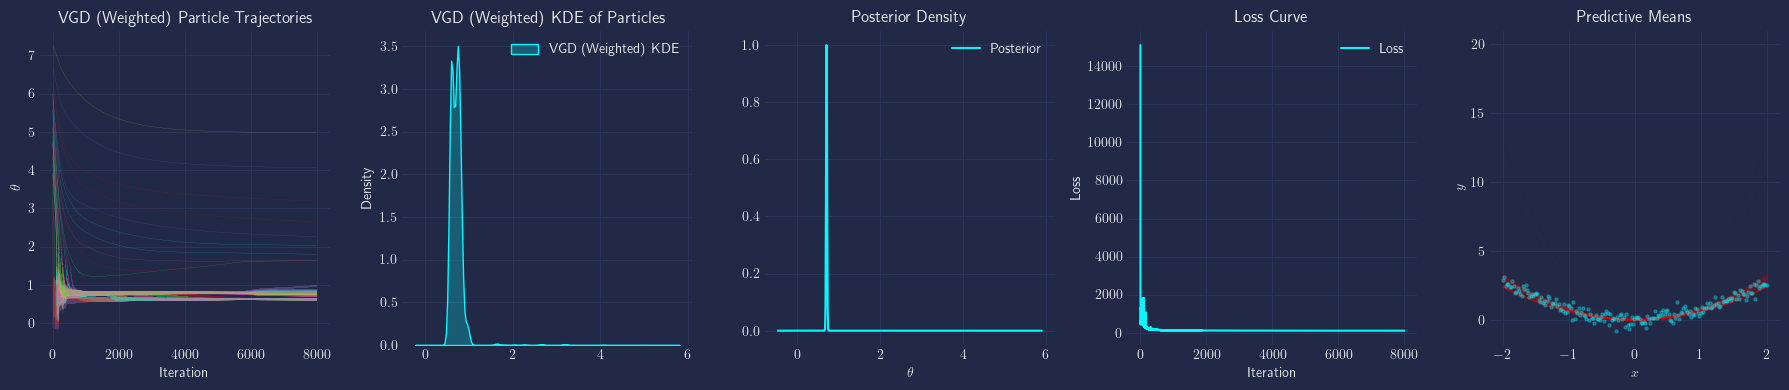

In [38]:
plot_1d_output(Q_vgdweight_quad, hist_vgdweight_quad, post_quad, algo_name="VGD (Weighted)", use_weights=True)

#### Misspecified

In [39]:
key, subkey = jax.random.split(key)
prior_sample = prior.sample(subkey, (n_particles,1)) + 5
Q0 = DiscreteMixture(prior_sample)

out = vgd_weight(model=post_quad_mis, 
                 loss=loss, 
                 kernel=RBFKernel(), 
                 kparams=kparams, 
                 eps=0.01, 
                 Q0=Q0, 
                 steps=8000, 
                 use_median_lengthscale=True, 
                 return_metrics=True, 
                 step_clip=100.,
                 weight_ema=0.1, 
                 weight_update_every=100)

Q_vgdweight_mis_quad, hist_vgdweight_mis_quad = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD (Weighted) Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD (Weighted) KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

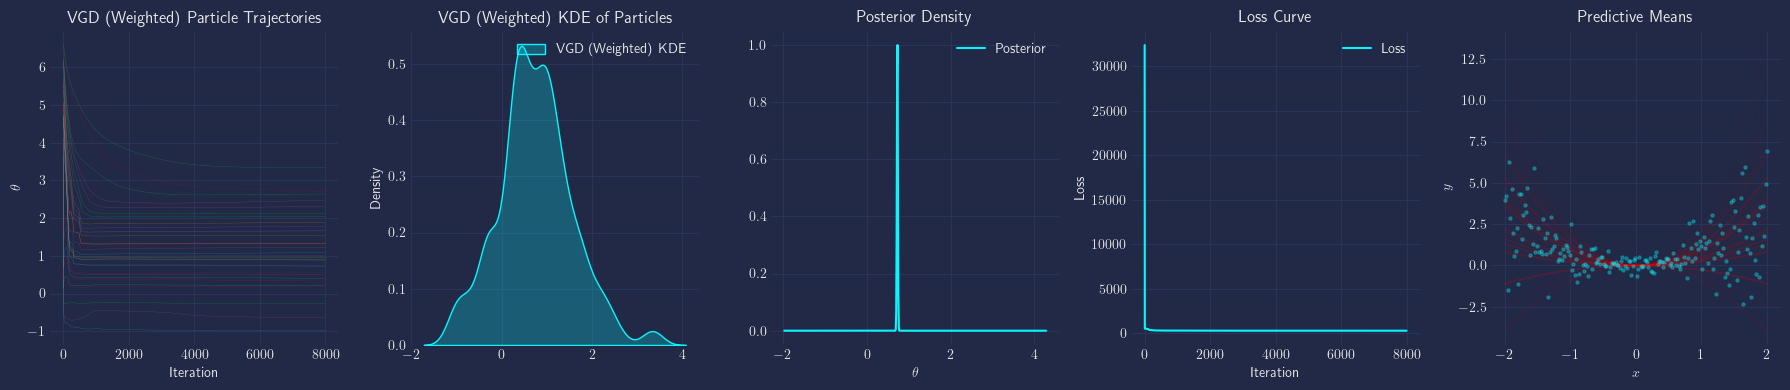

In [40]:
plot_1d_output(Q_vgdweight_mis_quad, hist_vgdweight_mis_quad, post_quad_mis, algo_name="VGD (Weighted)", use_weights=True)

### Sinusoidal

#### Well Specified

In [41]:
key, subkey = jax.random.split(key)
prior_sample = prior.sample(subkey, (n_particles,1)) + 5
Q0 = DiscreteMixture(prior_sample)

out = vgd_weight(model=post_sin, 
                 loss=loss, 
                 kernel=RBFKernel(), 
                 kparams=kparams, 
                 eps=0.01, 
                 Q0=Q0, 
                 steps=8000, 
                 use_median_lengthscale=True, 
                 return_metrics=True, 
                 step_clip=100.,
                 weight_ema=0.1, 
                 weight_update_every=100)

Q_vgdweight_sin, hist_vgdweight_sin = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD (Weighted) Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD (Weighted) KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

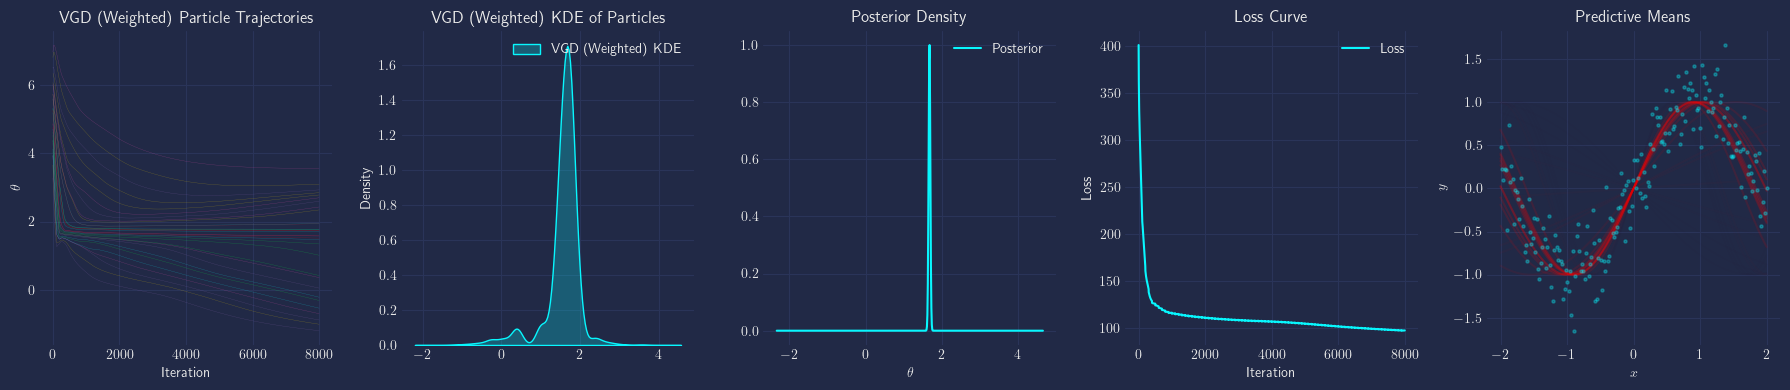

In [42]:
plot_1d_output(Q_vgdweight_sin, hist_vgdweight_sin, post_sin, algo_name="VGD (Weighted)", use_weights=True)

#### Misspecifed (Sinusoidal)

In [43]:
key, subkey = jax.random.split(key)
prior_sample = prior.sample(subkey, (n_particles,1)) + 5
Q0 = DiscreteMixture(prior_sample)

out = vgd_weight(model=post_sin_mis, 
                 loss=loss, 
                 kernel=RBFKernel(), 
                 kparams=kparams, 
                 eps=0.01, 
                 Q0=Q0, 
                 steps=8000, 
                 use_median_lengthscale=True, 
                 return_metrics=True, 
                 step_clip=100.,
                 weight_ema=0.1, 
                 weight_update_every=100)

Q_vgdweight_mis_sin, hist_vgdweight_mis_sin = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD (Weighted) Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD (Weighted) KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

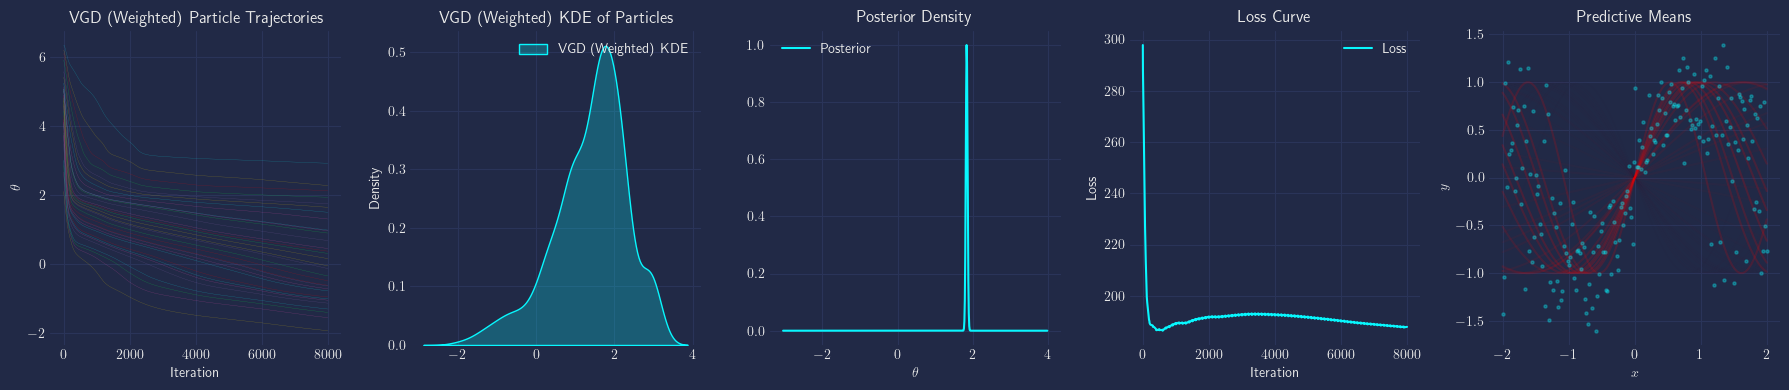

In [44]:
plot_1d_output(Q_vgdweight_mis_sin, hist_vgdweight_mis_sin, post_sin_mis, algo_name="VGD (Weighted)", use_weights=True)

#### Misspecifed (Quadratic)

In [45]:
key, subkey = jax.random.split(key)
prior_sample = prior.sample(subkey, (n_particles,1)) + 5
Q0 = DiscreteMixture(prior_sample)

out = vgd_weight(model=post_sin_mis_quad, 
                 loss=loss, 
                 kernel=RBFKernel(), 
                 kparams=kparams, 
                 eps=0.01, 
                 Q0=Q0, 
                 steps=8000, 
                 use_median_lengthscale=True, 
                 return_metrics=True, 
                 step_clip=100.,
                 weight_ema=0.1, 
                 weight_update_every=100)

Q_vgdweight_mis_sin_quad, hist_vgdweight_mis_sin_quad = out  # unpack

(<Figure size 1800x400 with 5 Axes>,
 array([<Axes: title={'center': 'VGD (Weighted) Particle Trajectories'}, xlabel='Iteration', ylabel='$\\theta$'>,
        <Axes: title={'center': 'VGD (Weighted) KDE of Particles'}, ylabel='Density'>,
        <Axes: title={'center': 'Posterior Density'}, xlabel='$\\theta$'>,
        <Axes: title={'center': 'Loss Curve'}, xlabel='Iteration', ylabel='Loss'>,
        <Axes: title={'center': 'Predictive Means'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

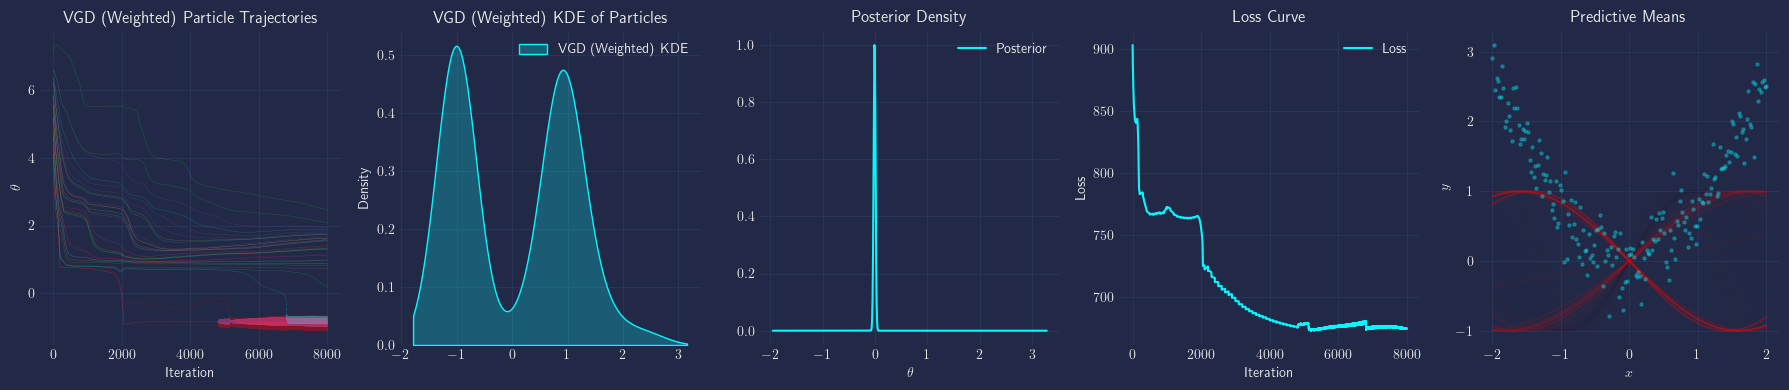

In [46]:
plot_1d_output(Q_vgdweight_mis_sin_quad, hist_vgdweight_mis_sin_quad, post_sin_mis_quad, algo_name="VGD (Weighted)", use_weights=True)

## TODO:

1. Implement Newton SVGD (https://arxiv.org/pdf/1806.03085)
2. Implement the Random SVGD and its Newton generalisation (https://arxiv.org/pdf/1812.00071 & https://arxiv.org/pdf/2204.09039)